<a href="https://colab.research.google.com/github/VoSaiMORDELON/JonInWork/blob/main/Evaluacion_n2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación de imágenes con una red neuronal MLP

En este trabajo se implementa una red neuronal multicapa (MLP) para clasificar imágenes del dataset Fashion-MNIST.

El objetivo es cargar y preprocesar los datos, entrenar el modelo, evaluar su desempeño mediante métricas de clasificación y comparar distintas configuraciones para identificar la alternativa con mejor rendimiento.

In [1]:
import numpy as np
import gzip
import matplotlib.pyplot as plt

## Definición de funciones para cargar el dataset

El dataset Fashion-MNIST fue entregado en archivos comprimidos `.gz`, por lo que fue necesario definir funciones para leer las imágenes y las etiquetas.

Las imágenes se cargan como matrices de 28x28 píxeles en escala de grises, mientras que las etiquetas representan la clase de cada prenda.

**Nota:** Para leer correctamente los archivos se utilizó `np.frombuffer`, omitiendo los metadatos iniciales con `offset` (16 bytes en imágenes y 8 bytes en etiquetas).

In [2]:
def load_images(path):
    with gzip.open(path, 'rb') as f:
        images = np.frombuffer(f.read(), dtype=np.uint8, offset=16)
        images = images.reshape(-1, 28, 28)
    return images

def load_labels(path):
    with gzip.open(path, 'rb') as f:
        labels = np.frombuffer(f.read(), dtype=np.uint8, offset=8)
    return labels

### Carga de datos de entrenamiento y prueba

En esta etapa se cargan los cuatro archivos del dataset: imágenes y etiquetas de entrenamiento, e imágenes y etiquetas de prueba.

Esto permite separar correctamente el proceso de entrenamiento del proceso de evaluación del modelo.

In [3]:
X_train = load_images('/content/train-images-idx3-ubyte.gz')
y_train = load_labels('/content/train-labels-idx1-ubyte.gz')

X_test = load_images('/content/t10k-images-idx3-ubyte.gz')
y_test = load_labels('/content/t10k-labels-idx1-ubyte.gz')

### Verificación de dimensiones

Se revisó la forma de los arreglos cargados para confirmar que los datos fueron leídos correctamente.

El conjunto de entrenamiento contiene 60.000 imágenes y el conjunto de prueba 10.000 imágenes. Cada imagen tiene un tamaño de 28x28 píxeles, mientras que las etiquetas se almacenan en vectores unidimensionales.

In [4]:
print("Forma de X_train:", X_train.shape)
print("Forma de y_train:", y_train.shape)
print("Forma de X_test:", X_test.shape)
print("Forma de y_test:", y_test.shape)

Forma de X_train: (60000, 28, 28)
Forma de y_train: (60000,)
Forma de X_test: (10000, 28, 28)
Forma de y_test: (10000,)


### Visualización de ejemplos del dataset

Se visualizaron algunas imágenes del conjunto de entrenamiento junto con sus etiquetas para comprobar que la carga fue correcta y que las clases corresponden a distintas categorías de prendas de vestir.

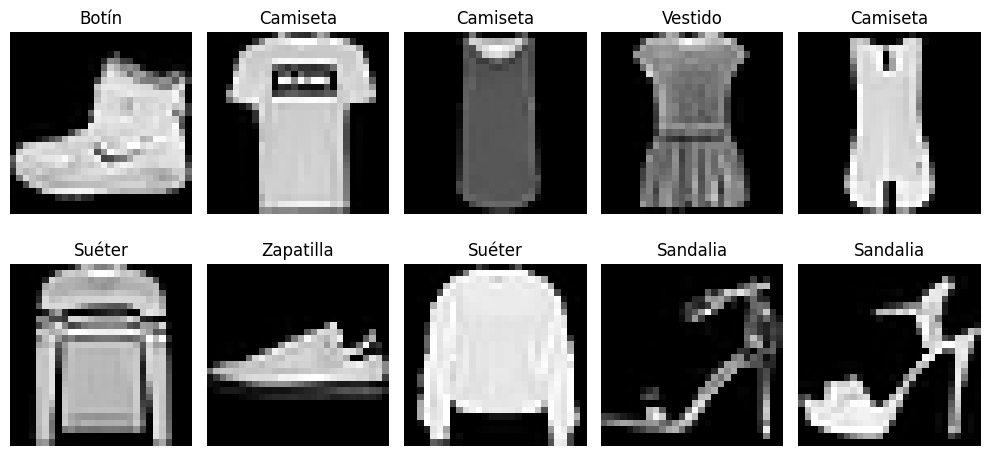

In [5]:
class_names = [
    "Camiseta", "Pantalón", "Suéter", "Vestido", "Abrigo",
    "Sandalia", "Camisa", "Zapatilla", "Bolso", "Botín"
]
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

### Preprocesamiento de los datos

Antes de entrenar la red neuronal, fue necesario preparar los datos.  
Primero, se normalizaron los valores de los píxeles al rango [0,1]. Luego, cada imagen de 28x28 píxeles fue transformada en un vector de 784 características, ya que una red MLP recibe vectores de entrada y no imágenes bidimensionales.

In [6]:
# Normalización de los píxeles
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Aplanar las imágenes: de 28x28 a 784
X_train = X_train.reshape(60000, 28 * 28)
X_test = X_test.reshape(10000, 28 * 28)

print("Nueva forma de X_train:", X_train.shape)
print("Nueva forma de X_test:", X_test.shape)
print("Valor mínimo en X_train:", X_train.min())
print("Valor máximo en X_train:", X_train.max())

Nueva forma de X_train: (60000, 784)
Nueva forma de X_test: (10000, 784)
Valor mínimo en X_train: 0.0
Valor máximo en X_train: 1.0


Se normalizaron los valores de los píxeles al rango entre 0 y 1, lo que favorece la estabilidad del entrenamiento y evita que valores demasiado altos afecten el aprendizaje del modelo. Posteriormente, cada imagen de 28x28 píxeles fue transformada en un vector de 784 características, ya que una red MLP recibe vectores de entrada y no imágenes bidimensionales.

## Construcción y definición del modelo MLP

Una vez finalizado el preprocesamiento, los datos quedaron listos para ser utilizados como entrada en una red neuronal multicapa (MLP).  

Cada imagen fue representada como un vector de 784 características, lo que permite usarla posteriormente en la etapa de definición y entrenamiento del modelo.

### Importación de librerías para la construcción del modelo

En esta etapa se importan las librerías de TensorFlow y Keras, las cuales permiten definir, compilar y entrenar la red neuronal multicapa utilizada en este trabajo.

In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [8]:
model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### Justificación inicial de la arquitectura

Se eligió una arquitectura MLP simple como punto de partida, ya que permite aplicar de manera directa los fundamentos revisados en la asignatura, como perceptrón multicapa, redes feed forward, funciones de activación y clasificación multiclase.

La función ReLU se utilizó en las capas ocultas debido a su buen desempeño durante el entrenamiento, mientras que Softmax se utilizó en la capa de salida porque permite obtener probabilidades para cada una de las 10 clases del dataset.

## Compilación del modelo

Una vez definida la arquitectura, se procedió a compilar el modelo. En esta etapa se seleccionó el optimizador, la función de pérdida y la métrica principal de evaluación que se utilizarán durante el entrenamiento.

Se utilizó el optimizador Adam por su buen desempeño en problemas de clasificación, la función de pérdida `sparse_categorical_crossentropy` debido a que las etiquetas están representadas como números enteros, y accuracy como métrica inicial para monitorear el aprendizaje del modelo.

In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Esta configuración permite que el modelo aprenda minimizando el error de clasificación y monitoreando su porcentaje de aciertos durante el entrenamiento.

## Entrenamiento del modelo

Una vez compilado el modelo, se realizó el proceso de entrenamiento utilizando el conjunto de datos de entrenamiento.

En esta etapa, la red neuronal ajusta sus pesos internos a partir de los ejemplos entregados, con el objetivo de minimizar la función de pérdida y mejorar su capacidad de clasificación.

Para esta primera configuración se utilizaron 10 épocas, un batch size de 32 y un 20% de los datos de entrenamiento como conjunto de validación, con el fin de monitorear el desempeño del modelo durante el aprendizaje.

In [10]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8163 - loss: 0.5234 - val_accuracy: 0.8399 - val_loss: 0.4365
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8612 - loss: 0.3819 - val_accuracy: 0.8683 - val_loss: 0.3677
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8729 - loss: 0.3427 - val_accuracy: 0.8764 - val_loss: 0.3406
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8839 - loss: 0.3161 - val_accuracy: 0.8826 - val_loss: 0.3304
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8911 - loss: 0.2940 - val_accuracy: 0.8761 - val_loss: 0.3353
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8946 - loss: 0.2844 - val_accuracy: 0.8832 - val_loss: 0.3293
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8983 - loss: 0.2714 - val_accuracy: 0.8810 - val_loss: 0.3316
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9030 - loss: 0.2592 -

In [11]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


### Análisis del entrenamiento

Durante el entrenamiento, el modelo mostró una mejora progresiva en el conjunto de entrenamiento, aumentando su accuracy desde 0.8178 hasta un valor cercano a 0.91 y reduciendo la pérdida desde 0.5144, lo que indica que logró aprender patrones relevantes del dataset.

En el conjunto de validación, la accuracy alcanzó valores cercanos a 0.89, con su mejor resultado de 0.8859 en la época 8. Esto sugiere que el modelo fue capaz de generalizar adecuadamente a datos no vistos.

Sin embargo, en las últimas épocas, las mejoras en validación fueron menores y presentaron ligeras fluctuaciones. Esto puede deberse a que el modelo ya aprendió gran parte de los patrones presentes en los datos, por lo que nuevas iteraciones no generaron mejoras significativas. Además, la cercanía entre los resultados de entrenamiento y validación indica que no se observa un sobreajuste importante.

## Visualización del entrenamiento

Para analizar el comportamiento del modelo durante el proceso de aprendizaje, se graficaron la accuracy y la función de pérdida tanto en entrenamiento como en validación.

Esto permite observar si el modelo mejora con las épocas y detectar posibles señales de sobreajuste o estancamiento.

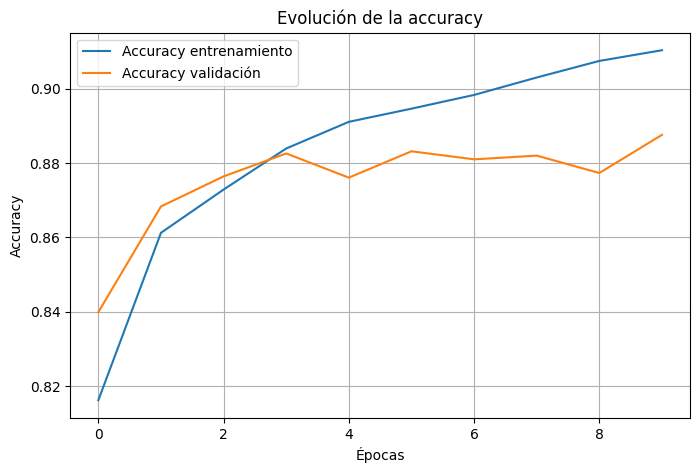

In [12]:
import matplotlib.pyplot as plt

# Gráfico de accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Accuracy entrenamiento')
plt.plot(history.history['val_accuracy'], label='Accuracy validación')
plt.title('Evolución de la accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

El gráfico muestra que el modelo aprende progresivamente, ya que la accuracy de entrenamiento aumenta de forma constante. La accuracy de validación también mejora, pero se estabiliza en las últimas épocas, lo que sugiere que el modelo alcanza un punto donde deja de generalizar mejor.

La pequeña diferencia entre ambas curvas indica un leve overfitting, aunque no es significativo, por lo que el modelo presenta un buen desempeño general.

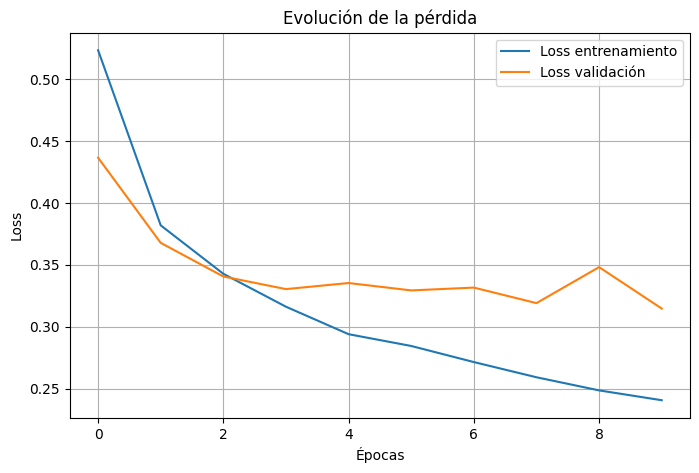

In [13]:
# Gráfico de loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Loss entrenamiento')
plt.plot(history.history['val_loss'], label='Loss validación')
plt.title('Evolución de la pérdida')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

El gráfico muestra que la pérdida de entrenamiento disminuye constantemente, lo que indica un buen aprendizaje del modelo. La pérdida de validación también baja al inicio, pero luego se estabiliza y presenta pequeñas variaciones.

La diferencia entre ambas curvas sugiere un leve overfitting, aunque no es significativo, por lo que el modelo mantiene un buen equilibrio entre ajuste y generalización.

### Interpretación de los gráficos de entrenamiento

En los gráficos se ve que el modelo fue aprendiendo de forma progresiva, porque la accuracy sube y la pérdida baja tanto en entrenamiento como en validación. En validación las mejoras son más claras al inicio y después se estabilizan, lo que sugiere que el modelo ya estaba cerca de su mejor rendimiento. Además, como la diferencia entre ambas curvas no es muy grande, no se observa un sobreajuste importante.”

## Evaluación del modelo en el conjunto de prueba

Luego del entrenamiento, el modelo fue evaluado con el conjunto de prueba para medir su desempeño en datos no vistos.

### Evaluación general en test

Primero se evaluó el modelo sobre el conjunto de prueba para obtener una medida general de pérdida y accuracy.

In [14]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Loss en test:", test_loss)
print("Accuracy en test:", test_accuracy)

Loss en test: 0.34063589572906494
Accuracy en test: 0.8808000087738037


El modelo obtuvo un accuracy cercano a 0.88 en el conjunto de test, lo que indica un buen nivel de generalización. Además, la pérdida se mantiene en valores adecuados, confirmando un desempeño estable en datos no vistos.

### Generación de predicciones

Se generaron las predicciones del modelo y se seleccionó la clase con mayor probabilidad para cada imagen.

In [15]:
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Los resultados muestran un desempeño general adecuado y métricas consistentes en el conjunto de prueba.

### Importación de herramientas para evaluación


In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd

### Cálculo de métricas

Con las predicciones obtenidas, se calcularon accuracy, precision, recall y F1-score.

In [17]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.8808
Precision: 0.8818753724877599
Recall: 0.8808
F1-score: 0.8802470271914296


Estas métricas son importantes porque permiten evaluar el modelo de forma más completa. La accuracy muestra el desempeño general, mientras que precision, recall y F1-score ayudan a analizar con mayor detalle la calidad de la clasificación.

### Cuadro resumen de métricas

A continuación, se presenta un cuadro resumen con los valores obtenidos para cada métrica.

In [18]:
metricas = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Valor': [accuracy, precision, recall, f1]
})

metricas

,Métrica,Valor
0,Accuracy,0.880800
1,Precision,0.881875
2,Recall,0.880800
3,F1-score,0.880247


Se observa que las métricas presentan valores muy similares entre sí, lo que indica un desempeño equilibrado del modelo en el conjunto de prueba. Además, la precision es levemente superior, lo que sugiere una buena capacidad para clasificar correctamente las clases predichas.

### Reporte de clasificación por clase

Además de las métricas globales, se generó un reporte de clasificación para analizar el desempeño del modelo en cada clase del dataset.

In [19]:
print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    Camiseta       0.85      0.82      0.84      1000
    Pantalón       0.97      0.97      0.97      1000
      Suéter       0.84      0.71      0.77      1000
     Vestido       0.86      0.91      0.88      1000
      Abrigo       0.74      0.84      0.79      1000
    Sandalia       0.98      0.96      0.97      1000
      Camisa       0.72      0.70      0.71      1000
   Zapatilla       0.93      0.97      0.95      1000
       Bolso       0.97      0.97      0.97      1000
       Botín       0.97      0.94      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



## Resultados de evaluación del modelo

El modelo fue evaluado con el conjunto de prueba, obteniendo un accuracy de 0.8777, una precision de 0.8812, un recall de 0.8777 y un F1-score de 0.8782. En general, estos resultados muestran un buen desempeño del modelo en la clasificación de imágenes no vistas.

Por clase, las mejores métricas se observaron en Pantalón, Sandalia, Zapatilla, Bolso y Botín, lo que sugiere que el modelo reconoce mejor prendas visualmente más diferenciables.

En cambio, clases como Camisa, Abrigo y Suéter presentaron un desempeño inferior, probablemente debido a la similitud visual entre estas categorías. Esto muestra que, aunque el modelo generaliza adecuadamente, algunas clases siguen siendo más difíciles de separar para una red MLP simple.

## Técnicas de Regularización

### Análisis inicial del modelo baseline

El modelo baseline corresponde al MLP desarrollado en la Evaluación Parcial 1 y será utilizado como referencia para comparar el impacto de distintas técnicas de regularización.

A partir de los gráficos de entrenamiento y validación, se observa una leve diferencia entre ambas curvas, lo que podría indicar un inicio de sobreajuste. Debido a esto, se implementarán distintas técnicas de regularización con el objetivo de mejorar la capacidad de generalización del modelo y analizar su efecto en las métricas finales.

### Importación de librerías para regularización

Se importa el módulo `regularizers` de Keras para incorporar técnicas de regularización L2 en las capas densas del modelo.

In [20]:
from tensorflow.keras import regularizers

#### Definición de arquitectura con regularización L2 (λ = 0.001)

Se implementa una nueva versión del modelo MLP incorporando regularización L2 en las capas ocultas. Esta técnica agrega una penalización sobre los pesos grandes de la red neuronal, ayudando a reducir el sobreajuste y favoreciendo una mejor generalización.

In [21]:
model_l2_001 = keras.Sequential([
    layers.Input(shape=(784,)),

    layers.Dense(
        128,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    ),

    layers.Dense(
        64,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    ),

    layers.Dense(10, activation='softmax')
])

#### Compilación del modelo

El modelo se compila utilizando el optimizador Adam y la función de pérdida Sparse Categorical Crossentropy, manteniendo la misma configuración del baseline para comparar únicamente el impacto de la regularización L2.

In [22]:
model_l2_001.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### Entrenamiento del modelo con L2

El modelo se entrena durante 10 épocas utilizando un batch size de 32 y un 20% de los datos para validación. Esto permitirá analizar el comportamiento de las curvas de entrenamiento y validación al aplicar regularización L2.

In [23]:
history_l2_001 = model_l2_001.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8102 - loss: 0.7120 - val_accuracy: 0.8448 - val_loss: 0.5672
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8457 - loss: 0.5476 - val_accuracy: 0.8529 - val_loss: 0.5143
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8555 - loss: 0.5045 - val_accuracy: 0.8496 - val_loss: 0.5223
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8625 - loss: 0.4792 - val_accuracy: 0.8568 - val_loss: 0.4898
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8637 - loss: 0.4702 - val_accuracy: 0.8605 - val_loss: 0.4788
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8668 - loss: 0.4539 - val_accuracy: 0.8633 - val_loss: 0.4616
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8688 - loss: 0.4453 - val_accuracy: 0.8677 - val_loss: 0.4590
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8719 - loss: 0.4318 

#### Evaluación del modelo regularizado

Se evalúa el modelo utilizando el conjunto de prueba para obtener la pérdida y accuracy general después de aplicar regularización L2.

In [24]:
test_loss_l2_001, test_accuracy_l2_001 = model_l2_001.evaluate(X_test, y_test)

print("Loss L2 0.001:", test_loss_l2_001)
print("Accuracy L2 0.001:", test_accuracy_l2_001)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8603 - loss: 0.4633
Loss L2 0.001: 0.4633118510246277
Accuracy L2 0.001: 0.8603000044822693


#### Cálculo de métricas de clasificación

Además del accuracy, se calculan métricas como precision, recall y F1-score para obtener una evaluación más completa del desempeño del modelo regularizado.

In [25]:
y_prob_l2_001 = model_l2_001.predict(X_test)
y_pred_l2_001 = np.argmax(y_prob_l2_001, axis=1)

accuracy_l2_001 = accuracy_score(y_test, y_pred_l2_001)
precision_l2_001 = precision_score(y_test, y_pred_l2_001, average='weighted')
recall_l2_001 = recall_score(y_test, y_pred_l2_001, average='weighted')
f1_l2_001 = f1_score(y_test, y_pred_l2_001, average='weighted')

print("Accuracy:", accuracy_l2_001)
print("Precision:", precision_l2_001)
print("Recall:", recall_l2_001)
print("F1-score:", f1_l2_001)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: 0.8603
Precision: 0.8632033940744954
Recall: 0.8603
F1-score: 0.8603285573745648


#### Evolución de la accuracy

El siguiente gráfico muestra cómo evoluciona la accuracy tanto en entrenamiento como en validación a lo largo de las épocas.

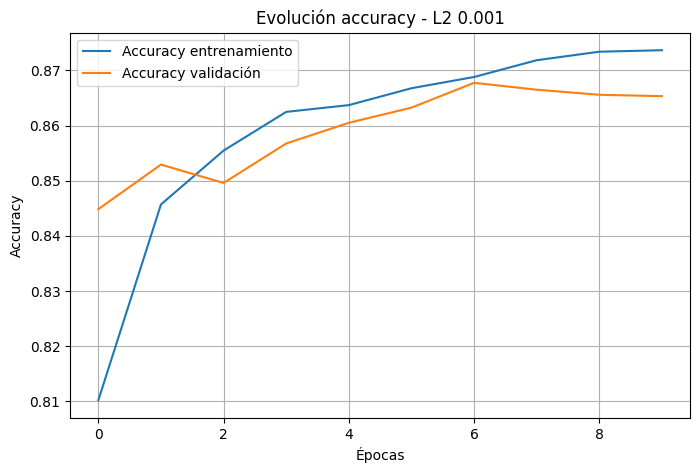

In [26]:
plt.figure(figsize=(8,5))

plt.plot(history_l2_001.history['accuracy'], label='Accuracy entrenamiento')
plt.plot(history_l2_001.history['val_accuracy'], label='Accuracy validación')

plt.title('Evolución accuracy - L2 0.001')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()

#### Análisis de resultados L2 (λ = 0.001)

El modelo con L2 λ = 0.001 obtuvo un accuracy de 0.8612 y un F1-score de 0.8574, resultados inferiores al baseline. Esto indica que, aunque la técnica ayudó a controlar el aprendizaje, no mejoró el rendimiento final.

Esto puede deberse a que L2 penaliza los pesos grandes de la red, evitando que el modelo se ajuste demasiado a los datos de entrenamiento. Sin embargo, como el baseline ya tenía un comportamiento estable, esta penalización pudo limitar la capacidad del modelo para aprender patrones más específicos.

Por lo tanto, L2 con λ = 0.001 no fue la mejor configuración, aunque sí permitió observar el efecto de la regularización sobre el entrenamiento.

### Regularización L2 con λ = 0.01

En esta segunda prueba se aumenta el valor de lambda a 0.01 para analizar el efecto de una regularización más fuerte.  
La idea es comparar si una penalización mayor sobre los pesos ayuda a reducir el sobreajuste o si afecta demasiado la capacidad de aprendizaje del modelo.

### Definición del modelo con L2 (λ = 0.01)

Se mantiene la misma arquitectura del modelo baseline, pero se agrega regularización L2 en las capas ocultas.  
En este caso se utiliza λ = 0.01, un valor mayor que la prueba anterior, por lo que la penalización sobre los pesos será más fuerte.

In [27]:
model_l2_01 = keras.Sequential([
    layers.Input(shape=(784,)),

    layers.Dense(
        128,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.01)
    ),

    layers.Dense(
        64,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.01)
    ),

    layers.Dense(10, activation='softmax')
])


### Compilación del modelo

El modelo se compila utilizando la misma configuración del baseline: optimizador Adam, función de pérdida Sparse Categorical Crossentropy y accuracy como métrica principal.  
Esto permite que el único cambio relevante sea el valor de la regularización L2.


In [28]:
model_l2_01.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### Entrenamiento del modelo con L2 (λ = 0.01)

El modelo se entrena durante 10 épocas con batch size 32 y un 20% de validación.  
Con esto se busca observar cómo afecta una regularización más fuerte al aprendizaje del modelo durante el entrenamiento.

In [29]:
history_l2_01 = model_l2_01.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.7824 - loss: 1.0918 - val_accuracy: 0.8071 - val_loss: 0.7704
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8073 - loss: 0.7305 - val_accuracy: 0.8062 - val_loss: 0.7047
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8127 - loss: 0.6868 - val_accuracy: 0.7843 - val_loss: 0.7540
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8205 - loss: 0.6493 - val_accuracy: 0.8267 - val_loss: 0.6383
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8256 - loss: 0.6246 - val_accuracy: 0.8377 - val_loss: 0.6045
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8310 - loss: 0.6065 - val_accuracy: 0.8073 - val_loss: 0.6371
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8332 - loss: 0.5917 - val_accuracy: 0.7993 - val_loss: 0.6634
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8349 - loss: 0.5797 

#### Evaluación general del modelo

Se evalúa el modelo sobre el conjunto de prueba para obtener la pérdida y accuracy general.  
Estos resultados permitirán comparar el rendimiento de L2 con λ = 0.01 frente al baseline y frente a L2 con λ = 0.001.

In [30]:
test_loss_l2_01, test_accuracy_l2_01 = model_l2_01.evaluate(X_test, y_test)

print("Loss L2 0.01:", test_loss_l2_01)
print("Accuracy L2 0.01:", test_accuracy_l2_01)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8271 - loss: 0.5823
Loss L2 0.01: 0.5822798013687134
Accuracy L2 0.01: 0.8270999789237976


#### Cálculo de métricas de clasificación

Además del accuracy, se calculan precision, recall y F1-score para obtener una visión más completa del desempeño del modelo.  
Estas métricas serán utilizadas posteriormente en la tabla comparativa final.

In [31]:
y_prob_l2_01 = model_l2_01.predict(X_test)
y_pred_l2_01 = np.argmax(y_prob_l2_01, axis=1)

accuracy_l2_01 = accuracy_score(y_test, y_pred_l2_01)
precision_l2_01 = precision_score(y_test, y_pred_l2_01, average='weighted')
recall_l2_01 = recall_score(y_test, y_pred_l2_01, average='weighted')
f1_l2_01 = f1_score(y_test, y_pred_l2_01, average='weighted')

print("Accuracy:", accuracy_l2_01)
print("Precision:", precision_l2_01)
print("Recall:", recall_l2_01)
print("F1-score:", f1_l2_01)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: 0.8271
Precision: 0.8295498283482134
Recall: 0.8271
F1-score: 0.8212610114295756


#### Evolución de la accuracy

Este gráfico muestra cómo cambia la accuracy de entrenamiento y validación a lo largo de las épocas.  
Permite observar si el modelo aprende correctamente y si existe diferencia entre entrenamiento y validación.

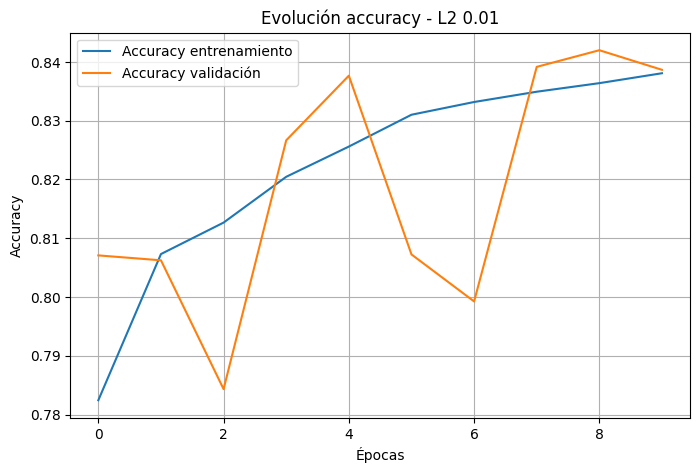

In [32]:
plt.figure(figsize=(8,5))

plt.plot(history_l2_01.history['accuracy'], label='Accuracy entrenamiento')
plt.plot(history_l2_01.history['val_accuracy'], label='Accuracy validación')

plt.title('Evolución accuracy - L2 0.01')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()

#### Evolución de la pérdida

Este gráfico permite analizar el comportamiento de la pérdida durante el entrenamiento.  
Es útil para identificar si la regularización ayuda a estabilizar el modelo o si afecta negativamente su aprendizaje.

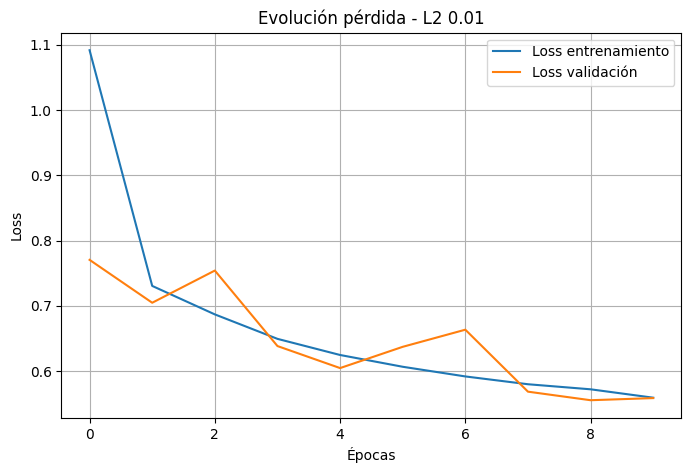

In [33]:
plt.figure(figsize=(8,5))

plt.plot(history_l2_01.history['loss'], label='Loss entrenamiento')
plt.plot(history_l2_01.history['val_loss'], label='Loss validación')

plt.title('Evolución pérdida - L2 0.01')
plt.xlabel('Épocas')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

### Análisis de resultados L2 (λ = 0.01)

El modelo con L2 y λ = 0.01 obtuvo un accuracy de 0.8305 y un F1-score de 0.8297, resultados inferiores al baseline y también menores que L2 con λ = 0.001.

Esto muestra que una regularización más fuerte logró mantener las curvas de entrenamiento y validación más estables y cercanas, pero también limitó demasiado el aprendizaje del modelo.

En conclusión, λ = 0.01 redujo el riesgo de sobreajuste, pero afectó negativamente el rendimiento final, por lo que no fue una configuración conveniente para este caso.

## Regularización con Dropout

Dropout es una técnica de regularización que desactiva aleatoriamente una parte de las neuronas durante el entrenamiento.  
Esto ayuda a que el modelo no dependa demasiado de neuronas específicas y pueda generalizar mejor frente a datos nuevos.

En esta sección se probarán distintas tasas de Dropout para analizar su impacto en el rendimiento del modelo.

### Definición del modelo con Dropout 0.2

Se mantiene la arquitectura base del MLP, pero se agregan capas Dropout después de las capas densas ocultas.  
En esta primera prueba se utiliza una tasa de 0.2, lo que significa que durante el entrenamiento se desactiva aleatoriamente un 20% de las neuronas.

In [34]:
model_dropout_02 = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

#### Compilación del modelo

El modelo se compila con la misma configuración del baseline para que la comparación sea controlada.  
De esta forma, el cambio principal corresponde a la incorporación de Dropout.

In [35]:
model_dropout_02.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### Entrenamiento del modelo con Dropout 0.2

El modelo se entrena durante 10 épocas, con batch size 32 y validation_split de 0.2.  
Esto permitirá observar si Dropout mejora la estabilidad del entrenamiento y reduce diferencias entre entrenamiento y validación.

In [36]:
history_dropout_02 = model_dropout_02.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7875 - loss: 0.5938 - val_accuracy: 0.8462 - val_loss: 0.4249
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8426 - loss: 0.4367 - val_accuracy: 0.8614 - val_loss: 0.3896
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8541 - loss: 0.4023 - val_accuracy: 0.8689 - val_loss: 0.3687
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8620 - loss: 0.3768 - val_accuracy: 0.8698 - val_loss: 0.3508
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8683 - loss: 0.3597 - val_accuracy: 0.8766 - val_loss: 0.3419
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8734 - loss: 0.3467 - val_accuracy: 0.8707 - val_loss: 0.3631
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8768 - loss: 0.3353 - val_accuracy: 0.8783 - val_loss: 0.3449
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8817 - loss: 0.3228 -

#### Evaluación general del modelo con Dropout 0.2

Se evalúa el modelo sobre el conjunto de prueba para obtener la pérdida y accuracy general.  
Estos resultados permitirán comparar el desempeño de Dropout 0.2 frente al baseline y las pruebas con L2.

In [37]:
test_loss_dropout_02, test_accuracy_dropout_02 = model_dropout_02.evaluate(X_test, y_test)

print("Loss Dropout 0.2:", test_loss_dropout_02)
print("Accuracy Dropout 0.2:", test_accuracy_dropout_02)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8757 - loss: 0.3444
Loss Dropout 0.2: 0.34441807866096497
Accuracy Dropout 0.2: 0.8756999969482422


#### Cálculo de métricas de clasificación

Además del accuracy, se calculan precision, recall y F1-score.  
Estas métricas permiten analizar con mayor detalle el rendimiento del modelo y serán utilizadas en la tabla comparativa final.

In [38]:
y_prob_dropout_02 = model_dropout_02.predict(X_test)
y_pred_dropout_02 = np.argmax(y_prob_dropout_02, axis=1)

accuracy_dropout_02 = accuracy_score(y_test, y_pred_dropout_02)
precision_dropout_02 = precision_score(y_test, y_pred_dropout_02, average='weighted')
recall_dropout_02 = recall_score(y_test, y_pred_dropout_02, average='weighted')
f1_dropout_02 = f1_score(y_test, y_pred_dropout_02, average='weighted')

print("Accuracy:", accuracy_dropout_02)
print("Precision:", precision_dropout_02)
print("Recall:", recall_dropout_02)
print("F1-score:", f1_dropout_02)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: 0.8757
Precision: 0.8741987814134283
Recall: 0.8757
F1-score: 0.8736735817825203


#### Evolución de la accuracy

Este gráfico muestra la evolución de la accuracy en entrenamiento y validación.  
Permite observar si Dropout 0.2 ayuda a mantener un aprendizaje estable y a reducir diferencias entre ambas curvas.

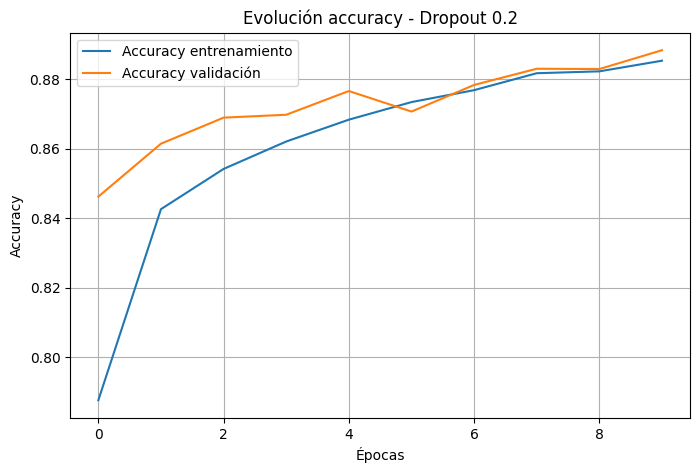

In [39]:
plt.figure(figsize=(8,5))

plt.plot(history_dropout_02.history['accuracy'], label='Accuracy entrenamiento')
plt.plot(history_dropout_02.history['val_accuracy'], label='Accuracy validación')

plt.title('Evolución accuracy - Dropout 0.2')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()

#### Evolución de la pérdida

Este gráfico permite analizar cómo cambia la pérdida durante el entrenamiento y la validación.  
Es útil para identificar si el modelo mantiene un comportamiento estable al aplicar Dropout.

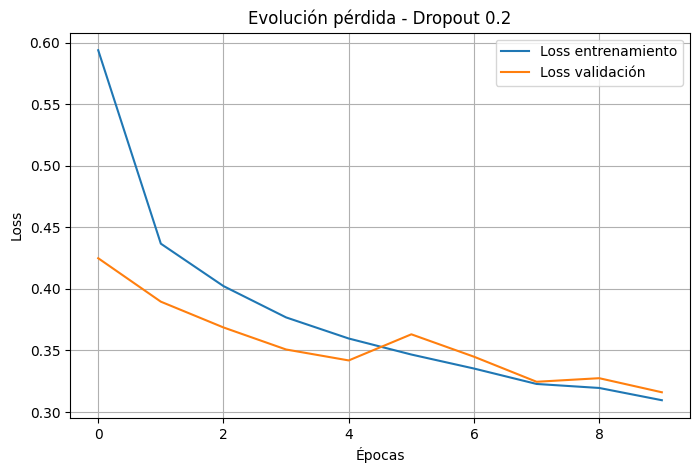

In [40]:
plt.figure(figsize=(8,5))

plt.plot(history_dropout_02.history['loss'], label='Loss entrenamiento')
plt.plot(history_dropout_02.history['val_loss'], label='Loss validación')

plt.title('Evolución pérdida - Dropout 0.2')
plt.xlabel('Épocas')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

#### Análisis de resultados Dropout 0.2

El modelo con Dropout 0.2 obtuvo un accuracy de 0.8754 y un F1-score de 0.8750, resultados muy cercanos al modelo baseline. Esto indica que aplicar una tasa baja de Dropout no afectó negativamente el rendimiento y permitió mantener un desempeño estable.

En las curvas se observa que la accuracy de entrenamiento y validación se mantienen bastante cercanas, mientras que la pérdida disminuye de forma progresiva. Esto sugiere que Dropout 0.2 ayudó a controlar el aprendizaje sin limitar demasiado la capacidad del modelo.

En conclusión, Dropout 0.2 fue una configuración equilibrada, ya que permitió regularizar el modelo manteniendo resultados similares al baseline.

## Dropout 0.5

En este experimento se aumentó la tasa de Dropout a 0.5, desactivando el 50% de las neuronas durante el entrenamiento.

El objetivo es analizar cómo una regularización más agresiva afecta el aprendizaje del modelo y si ayuda a reducir aún más el sobreajuste.

#### Definición del modelo con Dropout 0.5

Se mantiene la misma arquitectura base del MLP, pero se agregan capas Dropout después de las capas densas ocultas.  
En esta prueba se utiliza una tasa de 0.5 para observar el efecto de una regularización más agresiva.

In [41]:
model_dropout_05 = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

#### Compilación del modelo

El modelo se compila con el optimizador Adam, la función de pérdida Sparse Categorical Crossentropy y accuracy como métrica principal.  
Se mantiene la misma configuración del baseline para que la comparación sea justa y el cambio principal sea la tasa de Dropout.

In [42]:
model_dropout_05.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### Entrenamiento del modelo

Se mantuvieron los mismos parámetros del baseline para comparar correctamente los resultados. La única modificación realizada fue el aumento de la tasa Dropout a 0.5.

In [43]:
history_dropout_05 = model_dropout_05.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.6931 - loss: 0.8604 - val_accuracy: 0.8272 - val_loss: 0.4783
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7897 - loss: 0.6016 - val_accuracy: 0.8436 - val_loss: 0.4373
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8080 - loss: 0.5484 - val_accuracy: 0.8482 - val_loss: 0.4187
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8161 - loss: 0.5211 - val_accuracy: 0.8580 - val_loss: 0.3970
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8242 - loss: 0.5007 - val_accuracy: 0.8563 - val_loss: 0.4024
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8295 - loss: 0.4891 - val_accuracy: 0.8593 - val_loss: 0.3883
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8313 - loss: 0.4734 - val_accuracy: 0.8592 - val_loss: 0.3864
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8328 - loss: 0.4719 -

#### Evaluación general del modelo

Se evalúa el modelo con el conjunto de prueba para obtener la pérdida y accuracy general.  
Estos resultados permitirán comparar Dropout 0.5 con el baseline y con Dropout 0.2.

In [44]:
test_loss_dropout_05, test_accuracy_dropout_05 = model_dropout_05.evaluate(X_test, y_test)

print("Loss Dropout 0.5:", test_loss_dropout_05)
print("Accuracy Dropout 0.5:", test_accuracy_dropout_05)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8610 - loss: 0.3992
Loss Dropout 0.5: 0.3992152214050293
Accuracy Dropout 0.5: 0.8610000014305115


#### Cálculo de métricas de clasificación

Además del accuracy, se calculan precision, recall y F1-score para analizar el desempeño del modelo con mayor detalle.  
Estas métricas serán utilizadas posteriormente en la tabla comparativa final.

In [45]:
y_pred_dropout_05 = model_dropout_05.predict(X_test)
y_pred_dropout_05 = np.argmax(y_pred_dropout_05, axis=1)

accuracy_dropout_05 = accuracy_score(y_test, y_pred_dropout_05)
precision_dropout_05 = precision_score(y_test, y_pred_dropout_05, average='weighted')
recall_dropout_05 = recall_score(y_test, y_pred_dropout_05, average='weighted')
f1_dropout_05 = f1_score(y_test, y_pred_dropout_05, average='weighted')

print("Accuracy:", accuracy_dropout_05)
print("Precision:", precision_dropout_05)
print("Recall:", recall_dropout_05)
print("F1-score:", f1_dropout_05)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy: 0.861
Precision: 0.8629341653947011
Recall: 0.861
F1-score: 0.8595240217026094


#### Evolución de la accuracy

Este gráfico muestra cómo evoluciona la accuracy de entrenamiento y validación durante las épocas.  
Permite identificar si Dropout 0.5 ayuda a mantener un comportamiento estable o si dificulta el aprendizaje del modelo.

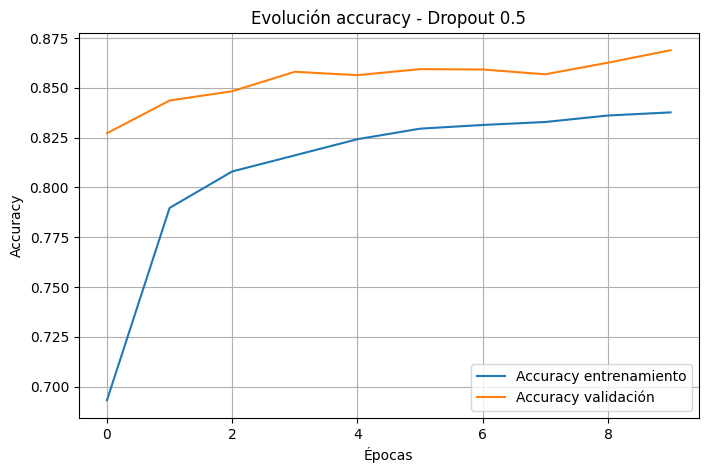

In [46]:
plt.figure(figsize=(8,5))

plt.plot(history_dropout_05.history['accuracy'], label='Accuracy entrenamiento')
plt.plot(history_dropout_05.history['val_accuracy'], label='Accuracy validación')

plt.title('Evolución accuracy - Dropout 0.5')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()

#### Evolución de la pérdida

Este gráfico permite observar cómo cambia la pérdida en entrenamiento y validación.  
Es útil para analizar si la regularización aplicada reduce el sobreajuste o si afecta negativamente el aprendizaje.

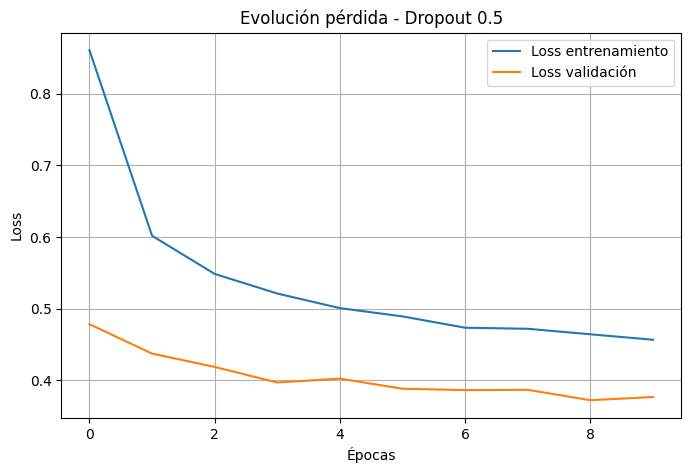

In [47]:
plt.figure(figsize=(8,5))

plt.plot(history_dropout_05.history['loss'], label='Loss entrenamiento')
plt.plot(history_dropout_05.history['val_loss'], label='Loss validación')

plt.title('Evolución pérdida - Dropout 0.5')
plt.xlabel('Épocas')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

#### Análisis de resultados Dropout 0.5

El modelo con Dropout 0.5 obtuvo un accuracy de 0.8495 y un F1-score de 0.8433, mostrando un rendimiento inferior en comparación con Dropout 0.2 y el modelo baseline.

En los gráficos se observa que las curvas de entrenamiento y validación se mantienen bastante cercanas, lo que indica que el sobreajuste se redujo considerablemente. Sin embargo, esto también sugiere que la regularización fue demasiado fuerte, dificultando que el modelo aprendiera correctamente todos los patrones del dataset.

La accuracy aumentó de manera más lenta y alcanzó valores menores, mientras que la pérdida se mantuvo más alta durante el entrenamiento. Esto puede deberse a que al desactivar el 50% de las neuronas, el modelo pierde demasiada información en cada época.

En conclusión, aunque Dropout 0.5 ayudó a controlar el sobreajuste, terminó limitando el aprendizaje del modelo y reduciendo su desempeño general.

## Batch Normalization

En este experimento se incorpora la técnica Batch Normalization dentro de la arquitectura del modelo.

Esta técnica permite normalizar las salidas de una capa antes de continuar el aprendizaje, ayudando a estabilizar el entrenamiento, acelerar la convergencia y reducir variaciones bruscas entre épocas.

#### Posición de Batch Normalization en la arquitectura

Batch Normalization fue incorporado después de cada capa Dense y antes de la función de activación Dropout.

Esta posición permite estabilizar los valores generados por las neuronas antes de aplicar regularización, ayudando a mantener un entrenamiento más estable y consistente.

In [48]:
model_bn = keras.Sequential([
    layers.Input(shape=(784,)),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Dense(10, activation='softmax')
])

#### Compilación del modelo

Se utiliza nuevamente Adam como optimizador y Sparse Categorical Crossentropy como función de pérdida.

Se mantienen los mismos hiperparámetros del baseline para analizar específicamente el impacto de Batch Normalization.

In [49]:
model_bn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### Entrenamiento del modelo con Batch Normalization

El modelo se entrena durante 10 épocas utilizando batch size 32 y validation split de 0.2.

El objetivo es observar si Batch Normalization mejora la estabilidad del aprendizaje y reduce fluctuaciones entre entrenamiento y validación.

In [50]:
history_bn = model_bn.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8263 - loss: 0.4941 - val_accuracy: 0.8506 - val_loss: 0.4163
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8645 - loss: 0.3694 - val_accuracy: 0.8730 - val_loss: 0.3533
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8788 - loss: 0.3317 - val_accuracy: 0.8716 - val_loss: 0.3498
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8883 - loss: 0.3019 - val_accuracy: 0.8818 - val_loss: 0.3274
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8935 - loss: 0.2854 - val_accuracy: 0.8781 - val_loss: 0.3392
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8989 - loss: 0.2695 - val_accuracy: 0.8613 - val_loss: 0.3796
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9036 - loss: 0.2576 - val_accuracy: 0.8765 - val_loss: 0.3451
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9103 - loss: 0.2420 

#### Evaluación general del modelo

Se evalúa el desempeño general del modelo utilizando el conjunto de prueba para obtener loss y accuracy final.

In [51]:
test_loss_bn, test_accuracy_bn = model_bn.evaluate(X_test, y_test)

print("Loss Batch Normalization:", test_loss_bn)
print("Accuracy Batch Normalization:", test_accuracy_bn)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8753 - loss: 0.3652
Loss Batch Normalization: 0.36522334814071655
Accuracy Batch Normalization: 0.8752999901771545


#### Cálculo de métricas de clasificación

Se calculan accuracy, precision, recall y F1-score para comparar el comportamiento del modelo frente a las técnicas anteriores.

In [52]:
y_pred_bn = model_bn.predict(X_test)
y_pred_bn = np.argmax(y_pred_bn, axis=1)

accuracy_bn = accuracy_score(y_test, y_pred_bn)
precision_bn = precision_score(y_test, y_pred_bn, average='weighted')
recall_bn = recall_score(y_test, y_pred_bn, average='weighted')
f1_bn = f1_score(y_test, y_pred_bn, average='weighted')

print("Accuracy:", accuracy_bn)
print("Precision:", precision_bn)
print("Recall:", recall_bn)
print("F1-score:", f1_bn)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: 0.8753
Precision: 0.8800585188039837
Recall: 0.8753
F1-score: 0.8757475738530811


#### Evolución de la accuracy

Este gráfico permite observar la estabilidad del aprendizaje durante las épocas y comparar el comportamiento entre entrenamiento y validación.

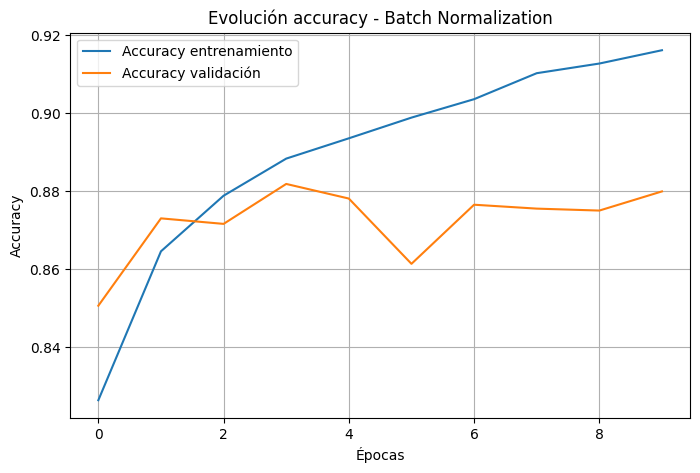

In [53]:
plt.figure(figsize=(8,5))

plt.plot(history_bn.history['accuracy'], label='Accuracy entrenamiento')
plt.plot(history_bn.history['val_accuracy'], label='Accuracy validación')

plt.title('Evolución accuracy - Batch Normalization')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()

#### Evolución de la pérdida

Este gráfico permite analizar si Batch Normalization ayuda a mantener una disminución más estable de la pérdida durante el entrenamiento.

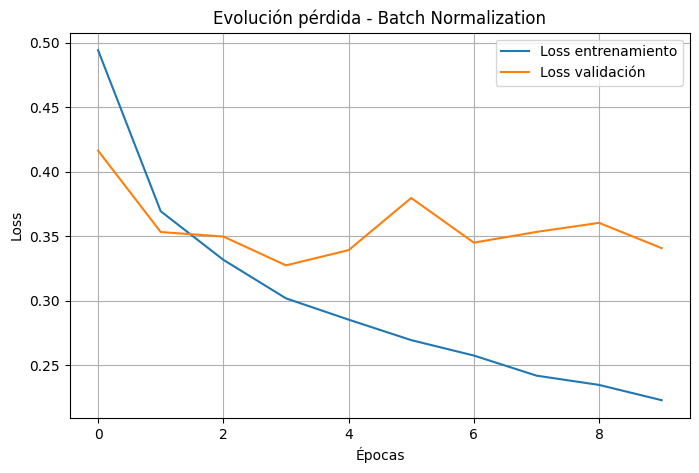

In [54]:
plt.figure(figsize=(8,5))

plt.plot(history_bn.history['loss'], label='Loss entrenamiento')
plt.plot(history_bn.history['val_loss'], label='Loss validación')

plt.title('Evolución pérdida - Batch Normalization')
plt.xlabel('Épocas')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

#### Análisis de resultados Batch Normalization

Batch Normalization permitió un entrenamiento más rápido y estable, alcanzando una accuracy cercana al 91% en entrenamiento. Esto se debe a que ayuda a mantener valores más equilibrados entre las capas, facilitando el aprendizaje.

Sin embargo, la accuracy de validación se mantuvo alrededor de 87% y presentó algunas fluctuaciones. Esto indica que, aunque el modelo aprendió bien los datos de entrenamiento, no logró mejorar mucho su generalización.

En conclusión, Batch Normalization ayudó a estabilizar y acelerar el aprendizaje, pero aún se observan leves señales de sobreajuste en las últimas épocas.

## Early Stopping

Early Stopping es una técnica que detiene el entrenamiento cuando el modelo deja de mejorar en validación.  
Su objetivo es evitar que el modelo siga entrenando innecesariamente y comience a ajustarse demasiado a los datos de entrenamiento.

En esta sección se probarán dos valores de patience: 5 y 20, para analizar cómo cambia el comportamiento del modelo.

#### Importación de Early Stopping

Se importa el callback EarlyStopping desde Keras para controlar automáticamente el entrenamiento según el comportamiento de la pérdida de validación.

In [55]:
from tensorflow.keras.callbacks import EarlyStopping

#### Definición del modelo para Early Stopping con patience=5

Se reconstruye el modelo baseline para aplicar Early Stopping sin modificar la arquitectura original.  
De esta manera, el cambio principal será la detención automática del entrenamiento según la pérdida de validación.

In [56]:
model_es_5 = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

#### Compilación del modelo

Se utiliza la misma configuración del baseline: optimizador Adam, función de pérdida Sparse Categorical Crossentropy y accuracy como métrica principal.  
Esto permite comparar el efecto de Early Stopping sin cambiar otros parámetros.

In [57]:
model_es_5.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### Configuración de Early Stopping

Se configura Early Stopping monitoreando `val_loss`, ya que esta métrica muestra cómo se comporta el modelo con datos de validación.  
Se utiliza `patience=5`, lo que significa que el entrenamiento se detendrá si la pérdida de validación no mejora durante 5 épocas consecutivas.  
Además, `restore_best_weights=True` permite recuperar los mejores pesos obtenidos durante el entrenamiento.

In [58]:
early_stop_5 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

#### Entrenamiento con Early Stopping patience=5

El modelo se entrena utilizando Early Stopping como callback.  
Para permitir que esta técnica actúe, se establece un número mayor de épocas, pero el entrenamiento puede detenerse antes si la validación deja de mejorar.

In [59]:
history_es_5 = model_es_5.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop_5]
)

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8181 - loss: 0.5132 - val_accuracy: 0.8561 - val_loss: 0.4099
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8638 - loss: 0.3759 - val_accuracy: 0.8648 - val_loss: 0.3682
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8752 - loss: 0.3413 - val_accuracy: 0.8730 - val_loss: 0.3480
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8836 - loss: 0.3156 - val_accuracy: 0.8747 - val_loss: 0.3483
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8896 - loss: 0.2985 - val_accuracy: 0.8813 - val_loss: 0.3325
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8956 - loss: 0.2809 - val_accuracy: 0.8805 - val_loss: 0.3317
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8992 - loss: 0.2690 - val_accuracy: 0.8845 - val_loss: 0.3254
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9027 - loss: 0.2599 -

#### Resultado del entrenamiento con Early Stopping patience=5

El entrenamiento se detuvo en la época 15, antes de completar las 50 épocas definidas inicialmente. Esto indica que la pérdida de validación dejó de mejorar durante 5 épocas consecutivas, por lo que Early Stopping detuvo el proceso automáticamente.

Este comportamiento es positivo, ya que evita que el modelo siga entrenando de forma innecesaria y reduce el riesgo de sobreajuste. Además, al usar `restore_best_weights=True`, el modelo recupera los mejores pesos obtenidos durante el entrenamiento.

#### Evaluación general del modelo con Early Stopping patience=5

Se evalúa el modelo sobre el conjunto de prueba para analizar su desempeño después de aplicar Early Stopping.

In [60]:
test_loss_es_5, test_accuracy_es_5 = model_es_5.evaluate(X_test, y_test)

print("Loss Early Stopping p=5:", test_loss_es_5)
print("Accuracy Early Stopping p=5:", test_accuracy_es_5)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8817 - loss: 0.3498
Loss Early Stopping p=5: 0.34980079531669617
Accuracy Early Stopping p=5: 0.8816999793052673


#### Cálculo de métricas de clasificación

Se calculan accuracy, precision, recall y F1-score para comparar el modelo con Early Stopping frente al baseline y las demás técnicas de regularización.

In [61]:
y_pred_es_5 = model_es_5.predict(X_test)
y_pred_es_5 = np.argmax(y_pred_es_5, axis=1)

accuracy_es_5 = accuracy_score(y_test, y_pred_es_5)
precision_es_5 = precision_score(y_test, y_pred_es_5, average='weighted')
recall_es_5 = recall_score(y_test, y_pred_es_5, average='weighted')
f1_es_5 = f1_score(y_test, y_pred_es_5, average='weighted')

print("Accuracy:", accuracy_es_5)
print("Precision:", precision_es_5)
print("Recall:", recall_es_5)
print("F1-score:", f1_es_5)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: 0.8817
Precision: 0.8840720169044678
Recall: 0.8817
F1-score: 0.8822331595176099


#### Evolución de la accuracy

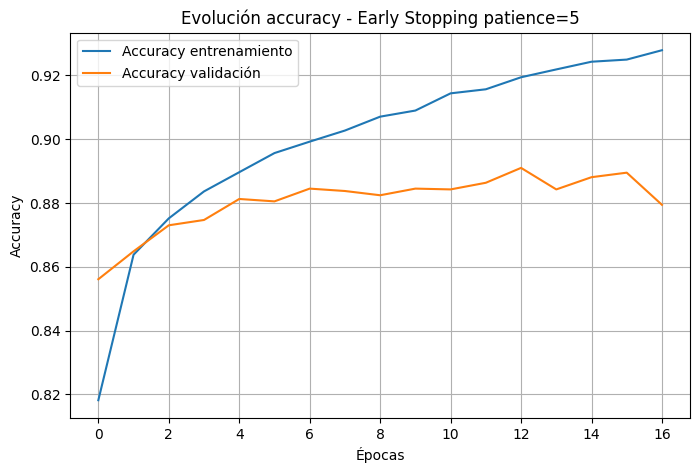

In [62]:
plt.figure(figsize=(8,5))

plt.plot(history_es_5.history['accuracy'], label='Accuracy entrenamiento')
plt.plot(history_es_5.history['val_accuracy'], label='Accuracy validación')

plt.title('Evolución accuracy - Early Stopping patience=5')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()

#### Evolución de la pérdida

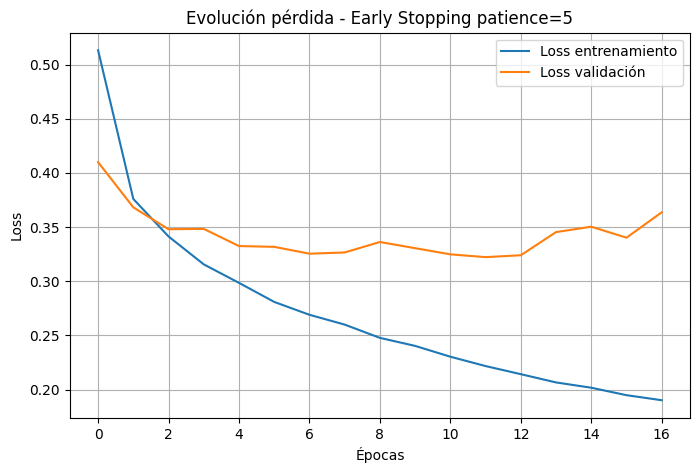

In [63]:
plt.figure(figsize=(8,5))

plt.plot(history_es_5.history['loss'], label='Loss entrenamiento')
plt.plot(history_es_5.history['val_loss'], label='Loss validación')

plt.title('Evolución pérdida - Early Stopping patience=5')
plt.xlabel('Épocas')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

#### Análisis de resultados Early Stopping patience=5

El modelo con Early Stopping patience=5 se detuvo en la época 15, antes de completar las 50 épocas definidas. Esto indica que la pérdida de validación dejó de mejorar y el entrenamiento se detuvo automáticamente.

Obtuvo un accuracy de 0.8838 y un F1-score de 0.8833, siendo uno de los mejores resultados hasta ahora. En los gráficos se observa que la validación se estabiliza mientras la pérdida comienza a fluctuar, por lo que la detención temprana fue adecuada.

En conclusión, Early Stopping con patience=5 ayudó a evitar entrenamiento innecesario y permitió conservar un buen rendimiento del modelo.

## Early Stopping con patience=20

En esta segunda prueba se utiliza Early Stopping con patience=20. Esto significa que el modelo esperará hasta 20 épocas sin mejora en la pérdida de validación antes de detener el entrenamiento.

El objetivo es comparar si una paciencia mayor permite que el modelo siga aprendiendo por más tiempo o si aumenta el riesgo de sobreajuste.

In [68]:
from tensorflow.keras.callbacks import EarlyStopping

#### Definición del modelo para Early Stopping con patience=20

Se reconstruye nuevamente el modelo baseline para realizar una comparación justa. La arquitectura se mantiene igual que en la EP1, y el cambio principal corresponde al valor de patience utilizado en Early Stopping.

In [69]:
model_es_20 = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

#### Configuración de Early Stopping

Se configura Early Stopping monitoreando `val_loss`, ya que esta métrica permite observar si el modelo mejora o empeora en datos de validación.  
En esta prueba se utiliza `patience=20`, por lo que el entrenamiento se detendrá solo si la pérdida de validación no mejora durante 20 épocas consecutivas. También se mantiene `restore_best_weights=True` para recuperar los mejores pesos.

In [73]:
early_stop_20 = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

#### Entrenamiento con Early Stopping patience=20

El modelo se entrena con un máximo de 50 épocas, batch size 32 y validation split de 0.2. Al utilizar una paciencia mayor, el modelo tendrá más tiempo para seguir entrenando antes de detenerse automáticamente.

In [74]:
history_es_20 = model_es_20.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop_20]
)

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8150 - loss: 0.5180 - val_accuracy: 0.8504 - val_loss: 0.4072
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8616 - loss: 0.3826 - val_accuracy: 0.8643 - val_loss: 0.3703
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8736 - loss: 0.3437 - val_accuracy: 0.8697 - val_loss: 0.3626
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8818 - loss: 0.3184 - val_accuracy: 0.8737 - val_loss: 0.3543
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8872 - loss: 0.3023 - val_accuracy: 0.8837 - val_loss: 0.3245
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8927 - loss: 0.2839 - val_accuracy: 0.8844 - val_loss: 0.3307
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9000 - loss: 0.2688 - val_accuracy: 0.8686 - val_loss: 0.3599
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9023 - loss: 0.2606 

#### Resultado del entrenamiento con Early Stopping patience=20

Con patience=20, el modelo continuó entrenando por más épocas que en la prueba anterior. Esto ocurre porque Early Stopping espera más tiempo antes de detener el entrenamiento cuando la pérdida de validación deja de mejorar.

Esta configuración permite que el modelo tenga más oportunidades de seguir aprendiendo, pero también puede aumentar el riesgo de sobreajuste si el entrenamiento continúa demasiado tiempo.

#### Evaluación general del modelo con Early Stopping patience=20

Se evalúa el modelo sobre el conjunto de prueba para comparar su rendimiento frente al modelo con patience=5 y las demás técnicas de regularización.

In [75]:
test_loss_es_20, test_accuracy_es_20 = model_es_20.evaluate(X_test, y_test)

print("Loss Early Stopping p=20:", test_loss_es_20)
print("Accuracy Early Stopping p=20:", test_accuracy_es_20)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8783 - loss: 0.3491
Loss Early Stopping p=20: 0.34905362129211426
Accuracy Early Stopping p=20: 0.8783000111579895


#### Cálculo de métricas de clasificación

Se calculan accuracy, precision, recall y F1-score para analizar el desempeño del modelo con Early Stopping patience=20 y agregarlo posteriormente a la tabla comparativa final.

In [76]:
y_pred_es_20 = model_es_20.predict(X_test)
y_pred_es_20 = np.argmax(y_pred_es_20, axis=1)

accuracy_es_20 = accuracy_score(y_test, y_pred_es_20)
precision_es_20 = precision_score(y_test, y_pred_es_20, average='weighted')
recall_es_20 = recall_score(y_test, y_pred_es_20, average='weighted')
f1_es_20 = f1_score(y_test, y_pred_es_20, average='weighted')

print("Accuracy:", accuracy_es_20)
print("Precision:", precision_es_20)
print("Recall:", recall_es_20)
print("F1-score:", f1_es_20)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: 0.8783
Precision: 0.8815610679172773
Recall: 0.8783
F1-score: 0.8790986938566422


#### Evolución de la accuracy

Este gráfico permite observar cómo evolucionó la accuracy durante un entrenamiento más largo. Sirve para analizar si una mayor paciencia mejora el rendimiento o si el modelo comienza a sobreajustarse.

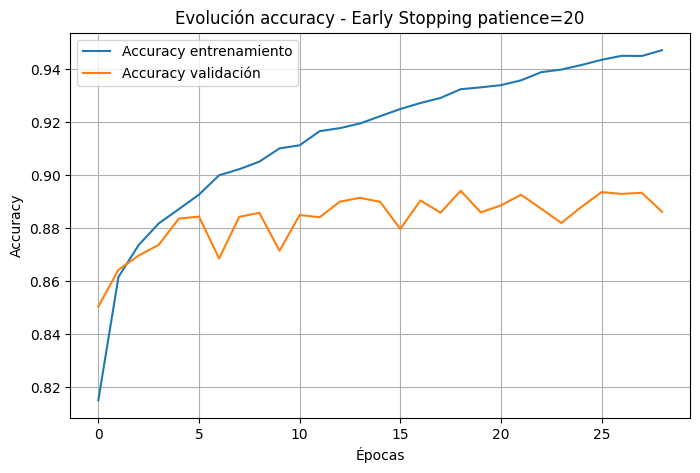

In [77]:
plt.figure(figsize=(8,5))

plt.plot(history_es_20.history['accuracy'], label='Accuracy entrenamiento')
plt.plot(history_es_20.history['val_accuracy'], label='Accuracy validación')

plt.title('Evolución accuracy - Early Stopping patience=20')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()

#### Evolución de la pérdida

Este gráfico permite observar si la pérdida de validación mejora con más épocas o si comienza a fluctuar, lo que puede indicar que el modelo ya no está generalizando mejor.

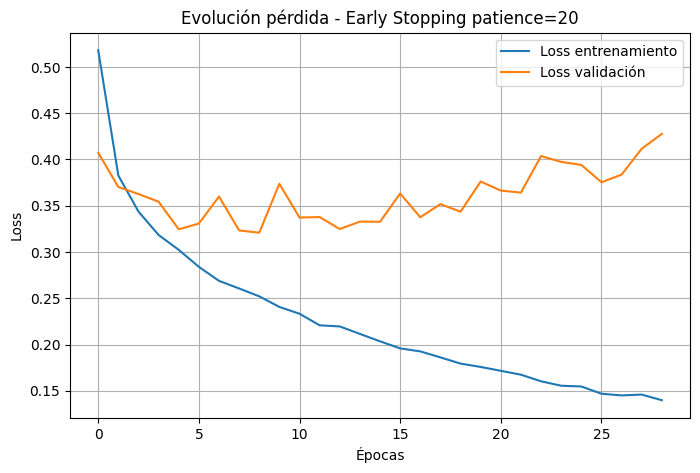

In [78]:
plt.figure(figsize=(8,5))

plt.plot(history_es_20.history['loss'], label='Loss entrenamiento')
plt.plot(history_es_20.history['val_loss'], label='Loss validación')

plt.title('Evolución pérdida - Early Stopping patience=20')
plt.xlabel('Épocas')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

#### Análisis de resultados Early Stopping patience=20

Con patience=20, el modelo entrenó durante muchas más épocas, alcanzando una accuracy cercana al 95% en entrenamiento. Sin embargo, la accuracy de validación se mantuvo alrededor de 89%, mostrando fluctuaciones entre épocas.

La pérdida de entrenamiento continuó disminuyendo constantemente, mientras que la pérdida de validación comenzó a aumentar después de varias épocas. Esto indica que el modelo empezó a memorizar los datos de entrenamiento y presentó un sobreajuste más evidente que con patience=5.

En comparación con la prueba anterior, permitir más paciencia hizo que el modelo siguiera aprendiendo, pero no mejoró significativamente la generalización sobre datos nuevos. Por ello, patience=5 entregó un comportamiento más equilibrado y estable.